In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split, ConcatDataset
import tifffile as tiff
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from PIL import Image
from tqdm import tqdm
from torchvision import transforms

from skimage import io
import sys
# from umap import UMAP
import joblib
from datetime import datetime

# Load Data
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:
# Get the directory of the script
script_dir = os.getcwd()

# Get the parent directory of the script
parent_dir = os.path.dirname(script_dir)

# Add the parent directory to sys.path
sys.path.append(parent_dir)

from core.autoencoders import AE, train_ae
from core.dataset import TIFFDataset
from utils.feature_analysis import UMAP_train, dataloader_model_latents,kmeans_cluster,DBSCAN_cluster
from utils.plotting_utils import umap_2Dplot, cluster_2Dplot



In [3]:
data_str = 'vin_pax_zyx_act'
pro_str = 'pax'
main_ch = 1
ctrl_y_str = 'ctrl_y'
input_ps = 32
latent_dim_array = [4,6,8,10,12,14,16,18,20]
BN_flag = True
dropout_flag = True
epochs = int(4000)
lr = 1e-4
eps = 2
min_samples = 5
kmeans_num_clusters = 6
loss_norm_flag = 0

dir_list = [
    '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/patches_gridonly_pslocation00/tiff_patches32_65p_20250909_1521',  # label 0
    '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/y_ch1_major/y_ch1_patches_gridonly_pslocation00/tiff_patches32_65p_20250909_1532',  # label 1   
    ]


In [4]:

transform = transforms.Compose([transforms.ToTensor()])

datasets = [
    TIFFDataset(root_dir=dir_path, label=label, transform=transform)
    for label, dir_path in enumerate(dir_list)
]

combined_dataset = ConcatDataset(datasets)

# Split dataset into training and validation sets
train_size = int(0.8 * len(combined_dataset))
val_size = len(combined_dataset) - train_size
train_dataset, val_dataset = random_split(combined_dataset, [train_size, val_size])
whole_data_loader = DataLoader(combined_dataset, batch_size=128, shuffle=True)
train_loader = DataLoader(combined_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(combined_dataset, batch_size=128, shuffle=False)



/mnt/d/lding/CLS_GitHub/fa_patch_AE_clustering/core/dataset.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32)  # shape: (1, H, W)


Epoch 80/4000, Train Loss: 0.0122, Val Loss: 0.0118
Epoch 160/4000, Train Loss: 0.0116, Val Loss: 0.0112
Epoch 240/4000, Train Loss: 0.0111, Val Loss: 0.0107
Epoch 320/4000, Train Loss: 0.0109, Val Loss: 0.0103
Epoch 400/4000, Train Loss: 0.0106, Val Loss: 0.0100
Input stats — min: 0.0000, max: 0.9486, mean: 0.0666, std: 0.0905
Reconstruction stats — min: 0.0084, max: 0.7734, mean: 0.0742, std: 0.0614
Epoch 480/4000, Train Loss: 0.0103, Val Loss: 0.0097
Epoch 560/4000, Train Loss: 0.0102, Val Loss: 0.0096


KeyboardInterrupt: 

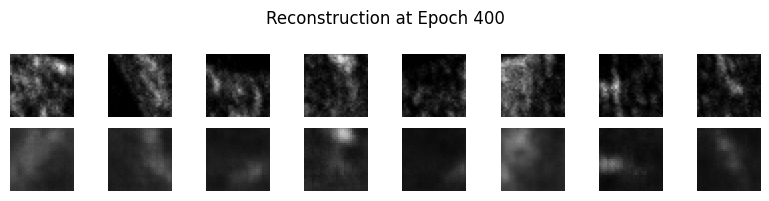

In [5]:
train_loss_across_latentdim = []
val_loss_across_latentdim = []



for  latent_dim in latent_dim_array:
        
    now = datetime.now()

    time_str = now.strftime("%Y%m%d_%H%M")

    result_dir = os.path.join('../results/', pro_str+'_ch' + str(main_ch) +'_'+ 'ps'+str(input_ps)+'_latdim_'+ str(latent_dim) +'_'+ time_str)
    os.makedirs(result_dir, exist_ok=True)

    # Train AE
    ae = AE(latent_dim=latent_dim, input_ps=input_ps, BN_flag=BN_flag, dropout_flag=dropout_flag).to(device)

    ae, train_losses, val_losses = train_ae(ae, train_loader, val_loader, device, epochs=epochs, lr=lr, loss_norm_flag=loss_norm_flag, result_dir = result_dir)

    train_loss_across_latentdim.append(train_losses[-1])
    val_loss_across_latentdim.append(val_losses[-1])
    
    latents, images, group_id = dataloader_model_latents(ae, whole_data_loader, device)

    if isinstance(group_id, torch.Tensor):
        group_id = group_id.cpu().numpy()
    elif isinstance(group_id, list):
        group_id = torch.cat(group_id).cpu().numpy()

    latents_2d = UMAP_train(latents, result_dir)

    DBSCAN, DBSCAN_labels =  DBSCAN_cluster(latents, eps=eps, min_samples=min_samples, result_dir=result_dir)

    kmeans, kmeans_labels = kmeans_cluster(latents, num_clusters=kmeans_num_clusters, result_dir=result_dir)

    fig = umap_2Dplot(latents_2d, 0,1,group_id)
    fig.savefig(os.path.join(result_dir, 'umap_2d_grouplabels.png'))

    fig = cluster_2Dplot(latents, 0,1,DBSCAN_labels)
    fig.savefig(os.path.join(result_dir, 'DBSCAN_latent01_labels.png'))
    
    fig = cluster_2Dplot(latents, 0,1,kmeans_labels)
    fig.savefig(os.path.join(result_dir, 'kmeans_latent01_labels.png'))

    fig = cluster_2Dplot(latents_2d, 0,1,DBSCAN_labels)
    fig.savefig(os.path.join(result_dir, 'DBSCAN_umap2d_labels.png'))
    
    fig = cluster_2Dplot(latents_2d, 0,1,kmeans_labels)
    fig.savefig(os.path.join(result_dir, 'kmeans_umap2d_labels.png'))


In [ ]:
# Plot training and validation loss
fig = plt.figure(figsize=(8, 6))
plt.plot(latent_dim_array, train_loss_across_latentdim, label='Train Loss')
plt.plot(latent_dim_array, val_loss_across_latentdim, label='Validation Loss')
plt.xlabel('Latent dim')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
fig.savefig(os.path.join('../results', 'latent_dim_train_val_losses'+pro_str+'_ch' + str(main_ch) +'_'+ 'ps'+str(input_ps)+'_latdim_'+ str(latent_dim) +'_'+ time_str+'.png'))

In [ ]:
train_losses